In [7]:
#!pip install statsforecast
#!pip install pmdarima


In [8]:
# Обработка данных
import pandas as pd
import numpy as np
import pmdarima as pm
# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import norm
from statsmodels.graphics.gofplots import qqplot


# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Модели ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Модель Prophet
import prophet as fp
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import add_changepoints_to_plot

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL as STL_decomp, MSTL as MSTL_decomp

# Настройка
import itertools
from tqdm import tqdm

import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

from statsforecast import StatsForecast
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL,
    AutoARIMA,
    SeasonalNaive,
    HistoricAverage,
    AutoETS,
    AutoTBATS,
    AutoCES,
    AutoTheta,
    HoltWinters
  )

from utilsforecast.losses import rmse, mape
from utilsforecast.evaluation import evaluate

In [10]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

Метрики возьмем RMSЕ, так как алкоголь имеет сезонные пики, важно не сильно ошибаться в эти периоды, а данная метрика чувствительна к большим ошибкам(квадратично штрафует за ошибки), и MAPE это удобная и понятная метрика, показывает на сколько процентов мы ошибаемся

Временной ряд продажи алкоголя в США с 1994 года по 2025

In [11]:
df = pd.read_csv('alcohol.csv', parse_dates=['observation_date'])
df.columns = ['ds','y']
df = df.set_index('ds')
df

,y
ds,
1994-01-01,3075
1994-02-01,3377
1994-03-01,4443
1994-04-01,4261
1994-05-01,4460
...,...
2025-04-01,15349
2025-05-01,15997
2025-06-01,16849


In [12]:
fig = px.line(df, x=df.index, y=df['y'], title="Продажа алкоголя в США")
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="обьем продаж млн.$")
fig.show()

Как видим из графика, временной ряд имеет восходящий тренд и явную сезонность. Причем дисперсия из года в год возрастает, что указывает на мультипликативность ряда.

In [13]:
train_size = int(len(df)*0.8)
train, test = df[:train_size], df[train_size:]

train.reset_index(inplace=True)
test.reset_index(inplace=True)

In [14]:
fig = px.line(title="Продажи алкоголя в США")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='test', line=dict(color='green'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="дата")
fig.update_yaxes(title_text="обьем продаж млн.$")
fig.show()

Мой временной ряд демонстрирует мультипликативный характер : имеет тренд и со временем увеличивается дисперсия, поэтому для декомпозиции будем использовать MSTL, применяя предварительное логарифмическое преобразование данных, так как по умолчанию MSTL предполагает аддитивность, а мой временной ряд имеет мультипликативный характер

In [15]:
train['log_y'] = np.log(train['y'])

fig = px.line(train, x=train.ds, y=train.log_y,
              title="Прологарифмированный временной ряд")

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.show()

Как видим из графика прологарифмированного временного ряда, тренд сохранился, а вот дисперсия выровнилась

MSTL разложение брала по 4, 6 и 12 месяцам соответственно. Период 12 месяцев соответствует годовой сезонности, которая явно присутствует в данных. Периоды 4 и 6 месяцев были выбраны для учета квартальных и полугодовых паттернов, которые могут быть связаны с сезонными праздниками и экономическими циклами. Подбирала вручную, опираясь на визуальную корректность разложения и способность компонент улавливать различные частоты сезонности.

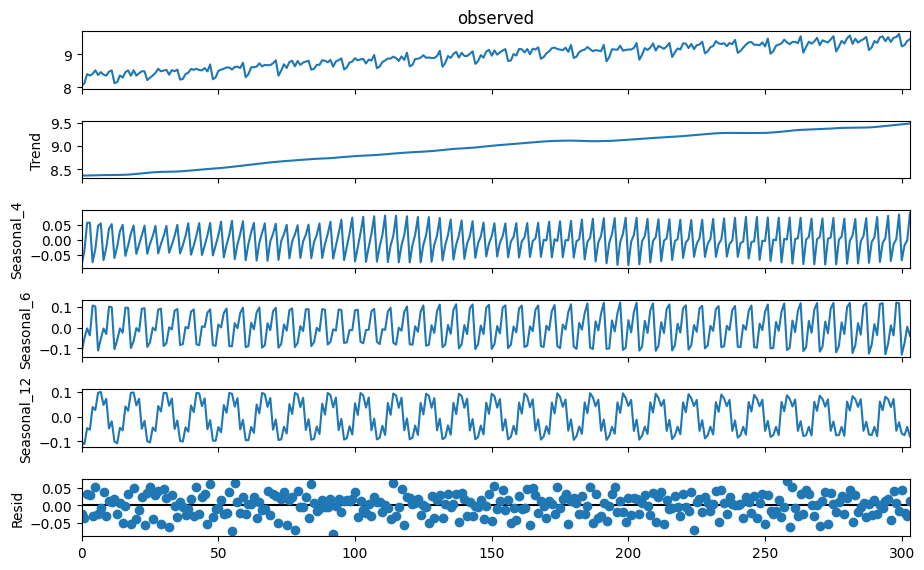

<Axes: >

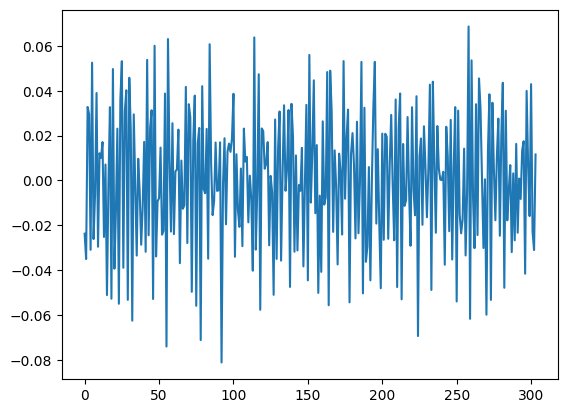

In [16]:
mstl_multi = MSTL_decomp(train['log_y'], periods=(4,6,12))
res_multi = mstl_multi.fit()

fig = res_multi.plot()
fig.set_size_inches(10, 6)
plt.show()

res_multi.resid.plot()

Разложение MSTL с периодами 4, 6 и 12 месяцев выглядит корректным: тренд выделен, а три сезонные компоненты явно улавливают повторяющиеся паттерны с разной частотой. Компонента seasonal_4 показывает частые колебания небольшой амплитуды,есть чётко повторяющийся паттерн с периодом 4 месяца. Такое же поведение у seasonal_6 и seasonal_12, это означает, что выбранные периоды 4, 6 и 12 хорошо объяснили сезонность.Остатки выглядят визуально как шум, без заметного тренда и их дисперсия примерно постоянна по всей длине ряда.

In [17]:
acorr_ljungbox(res_multi.resid, return_df=True)

,lb_stat,lb_pvalue
1,73.603170,9.551117e-18
2,73.678143,1.002293e-16
3,122.109592,2.710615e-26
4,192.478662,1.554647e-40
5,197.193608,1.131619e-40
6,202.124320,6.698890e-41
7,211.847099,3.541324e-42
8,218.222589,9.141540e-43
9,264.563181,8.355921e-52
10,325.470709,6.329801e-64


Из теста Льюнга-Бокса видим, что тест показывает наличие автокорреляции в остатках (p-value < 0.05 для большинства лагов до 10), что указывает на то, что модель не полностью уловила зависимость в данных.

In [18]:
adf_test(res_multi.resid)

Results of Dickey-Fuller Test:
Test Statistic                -7.418218e+00
p-value                        6.845357e-11
#Lags Used                     1.500000e+01
Number of Observations Used    2.880000e+02
Critical Value (1%)           -3.453262e+00
Critical Value (5%)           -2.871628e+00
Critical Value (10%)          -2.572146e+00
dtype: float64


ADF тест показывает, что остатки стационарны, так как мы отвергаем нулевую гипотезу (которая утверждает, что ряд нестационарен) при p-value < 0.05. То есть, в целом, остатки стационарные, но автокоррелированные. Лучше было бы, чтобы они были неавтокоррелированными. Поэтому попробуем смоделировать остатки с помощью auto ARIMA, чтобы она подобрала коэффициенты самостоятельно, а затем проверить остатки остатков на автокорреляцию и стационарность.

In [19]:
resid = res_multi.resid.dropna()

In [20]:
auto_model = pm.auto_arima( resid, d=None, stepwise=True, trace=True)

print(auto_model.summary())
arima_resid = auto_model.resid()


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-1420.887, Time=0.91 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-1247.915, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-1329.197, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-1341.317, Time=0.38 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1249.912, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-1348.694, Time=0.69 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-1436.798, Time=0.67 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-1344.465, Time=0.74 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-1364.408, Time=0.27 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-1398.921, Time=1.96 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-1397.399, Time=0.40 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=-1437.625, Time=2.39 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=-1412.945, Time=0.94 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=-1431.204, Time=0.77 sec
 ARIMA(2,0,3)(0,0,0

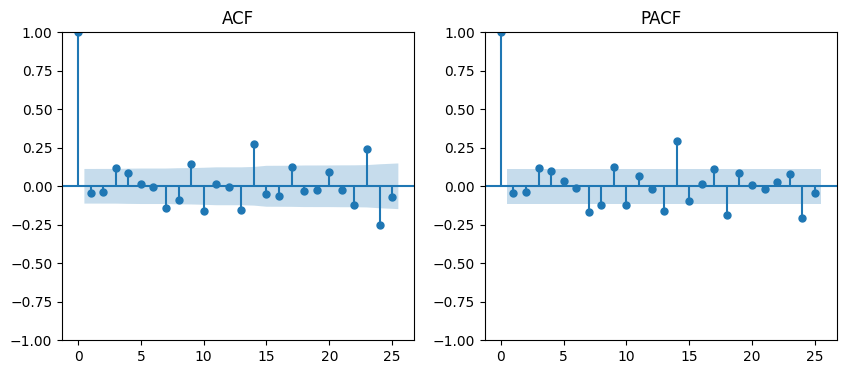

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(arima_resid, ax=ax[0])
ax[0].set_title('ACF')
plot_pacf(arima_resid, ax=ax[1])
ax[1].set_title('PACF')
plt.show()



Визуально автокорреляция отсутствует, значимых лагов нет.
На графике ACF, после первого лага, остальные точки в основном находятся в пределах доверительного интервала, за исключением нескольких незначительных всплесков, которые, вероятно, являются случайными.
На графике PACF, ситуация аналогична: большинство точек также находятся в пределах доверительного интервала, что указывает на отсутствие сильных статистически значимых корреляций на разных лагах

In [22]:
acorr_ljungbox(arima_resid, return_df=True)

,lb_stat,lb_pvalue
1,0.542797,0.461276
2,0.939916,0.625029
3,5.428519,0.142977
4,7.727827,0.102073
5,7.796810,0.167795
6,7.797735,0.253299
7,13.797830,0.054896
8,16.127496,0.040591
9,22.580085,0.007212
10,31.036235,0.000579


Как видим, тест Льюнга-Бокса для остатков остатков (после моделирования с помощью auto ARIMA) показывает, что автокорреляция отсутствует для большинства лагов до 7 (p-value > 0.05), что является улучшением по сравнению с исходными остатками декомпозиции.

In [23]:
adf_test(arima_resid)

Results of Dickey-Fuller Test:
Test Statistic                  -3.296638
p-value                          0.015029
#Lags Used                      16.000000
Number of Observations Used    287.000000
Critical Value (1%)             -3.453342
Critical Value (5%)             -2.871664
Critical Value (10%)            -2.572164
dtype: float64


А также ADF тест показывает, что остатки остатков стационарны (p-value = 0.015 < 0.05). В сочетании с отсутствием автокорреляции это означает, что нам удалось лучше учесть паттерны в данных, хотя полностью идеальными остатки не являются.

In [24]:
train['y_restored'] = np.exp(train['log_y'])

In [25]:
train.drop(['log_y', 'y_restored'], axis=1, inplace=True)

In [26]:
train['unique_id'] = 'alcohol_sale'
train

,ds,y,unique_id
0,1994-01-01,3075,alcohol_sale
1,1994-02-01,3377,alcohol_sale
2,1994-03-01,4443,alcohol_sale
3,1994-04-01,4261,alcohol_sale
4,1994-05-01,4460,alcohol_sale
...,...,...,...
299,2018-12-01,15135,alcohol_sale
300,2019-01-01,10353,alcohol_sale
301,2019-02-01,10764,alcohol_sale
302,2019-03-01,12228,alcohol_sale


# Модель SARIMA

In [27]:
models = [AutoARIMA(seasonal=True, season_length = 24, approximation=True)]
sf = StatsForecast(models=models, freq='M', n_jobs=-1)

sf.fit(df=train)
result = sf.fitted_[0][0].model_
forecast = sf.predict(h=len(test))

forecast.columns = ['unique_id', 'ds', 'y_hat']

fig = px.line(title="Продажи алкоголя модель SARIMA")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='предсказание модель SARIMA', line=dict(color='fuchsia'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()


In [28]:
def cv_sarima(train_data, n_splits=5):
    test_size = len(train_data) // (n_splits + 1)
    initial_size = len(train_data) - n_splits * test_size
    cv_rmse, cv_mape = [], []

    for i in range(n_splits):
        train_end = initial_size + i * test_size
        val_start, val_end = train_end, train_end + test_size
        if val_end > len(train_data):
            break

        train_cv = train_data.iloc[:train_end].copy()
        val_cv = train_data.iloc[val_start:val_end].copy()

        models_cv = [AutoARIMA(seasonal=True, season_length=24, approximation=True)]
        sf_cv = StatsForecast(models=models_cv, freq='M', n_jobs=-1)
        sf_cv.fit(df=train_cv)
        forecast_cv = sf_cv.predict(h=len(val_cv))
        forecast_cv.columns = ['unique_id', 'ds', 'y_hat']

        rmse_val = np.sqrt(mean_squared_error(val_cv['y'].values, forecast_cv['y_hat'].values))
        mape_val = np.mean(np.abs((val_cv['y'].values - forecast_cv['y_hat'].values) / val_cv['y'].values)) * 100
        cv_rmse.append(rmse_val)
        cv_mape.append(mape_val)

    return {
        'rmse_mean': np.mean(cv_rmse),
        'mape_mean': np.mean(cv_mape)
    }

cv_results_sarima_manual = cv_sarima(train, n_splits=5)
print(f"SARIMA: RMSE = {cv_results_sarima_manual['rmse_mean']:.2f} , MAPE = {cv_results_sarima_manual['mape_mean']:.2f}% ")

SARIMA: RMSE = 540.68 , MAPE = 5.46% 


Модель хорошо уловила динамику фактического ряда, это подтверждается невысоким RMSE 540.68 и относительно небольшим процентом отклонения 5.46%, в целом модель справилась с задачей и захватила основные паттерны. Также видно, что в начале тестового периода модель SARIMA хорошо уловила поведение ряда, а вот во второй половине явно продолжает возрастающий тренд, хотя фактический ряд идет чуть на спад.

# Модель SARIMAX с непрерывным регрессором уровень безработицыи dummy регрессором празничные дни

В качестве непрерывного регрессора возьмем уровень безработицы в США. Логика такая, что при росте безработицы люди начинают экономить, кто-то переходит на более дешевые марки или покупает алкоголь домой вместо баров. А также при росте безработицы у людей освобождается время и повышается уровень стресса и тревоги, и для некоторых людей это может послужить поводом к увеличению потребления алкоголя.

In [29]:
unemploy = pd.read_csv('unemployment_rate_monthly.csv', parse_dates=['date'])
unemploy.columns = ['ds','unemployment']
unemploy = unemploy.set_index('ds')
unemploy = unemploy.loc[df.index.min():df.index.max()]
unemploy

,unemployment
ds,
1994-01-01,6.6
1994-02-01,6.6
1994-03-01,6.5
1994-04-01,6.4
1994-05-01,6.1
...,...
2025-04-01,4.2
2025-05-01,4.2
2025-06-01,4.1


In [30]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['y'],
    mode='lines',
    name='продажи алкоголя в США',
    line=dict(color='blue'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=unemploy.index,
    y=unemploy['unemployment'],
    mode='lines',
    name='уровень безработицы',
    line=dict(color='red'),
    yaxis='y2'
))


fig.update_layout(
    title="Продажи алкоголя в США и уровень безработицы",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='продажи алкоголя в США',
    ),
    yaxis2=dict(
        title='уровень безработицы',
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Дата')
)

fig.show()

Как видим из совместного графика, продажи алкоголя и уровень безработицы демонстрируют разную динамику и не имеют явной сильной корреляции. Есть пик безработицы в годы ковида, что логично. Уровень безработицы со временем расширяет амплитуду колебания и имеет некую схожесть в тренде до примерно 2013 года. Для количественной оценки корреляции проверим коэффициент корреляции между регрессорами и целевой переменной.

In [ ]:
# Проверка корреляции регрессоров с целевой переменной
correlation_data = pd.merge(df[['y']], unemploy[['unemployment']], left_index=True, right_index=True, how='inner')
correlation_data['holiday'] = correlation_data.index.month.isin([1, 7, 9, 11, 12]).astype(int)

corr_unemployment = correlation_data['y'].corr(correlation_data['unemployment'])
corr_holiday = correlation_data['y'].corr(correlation_data['holiday'])

print(f"Корреляция между продажами алкоголя и уровнем безработицы: {corr_unemployment:.4f}")
print(f"Корреляция между продажами алкоголя и праздничными днями: {corr_holiday:.4f}")

# Визуализация корреляций
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(correlation_data['unemployment'], correlation_data['y'], alpha=0.5)
ax[0].set_xlabel('Уровень безработицы')
ax[0].set_ylabel('Продажи алкоголя')
ax[0].set_title(f'Корреляция: {corr_unemployment:.4f}')
ax[0].grid(True, alpha=0.3)

ax[1].scatter(correlation_data['holiday'], correlation_data['y'], alpha=0.5)
ax[1].set_xlabel('Праздничные дни (dummy)')
ax[1].set_ylabel('Продажи алкоголя')
ax[1].set_title(f'Корреляция: {corr_holiday:.4f}')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Так как период в моем временном ряду месячный, то я решила взять месяца основных праздников в США, такие как День благодарения, Новый год , Рождество ,День независимости и День памяти

In [31]:
holiday_months = [1, 7, 9, 11, 12]

holidays_dummy = pd.DataFrame(index=df.index)
holidays_dummy['main_holiday'] = holidays_dummy.index.month.isin(holiday_months).astype(int)

regressors = pd.merge(
    unemploy[['unemployment']],
    holidays_dummy[['main_holiday']],
    left_index=True, right_index=True,
    how='inner'
)
regressors['unique_id'] = 'alcohol_sale'

regressors


,unemployment,main_holiday,unique_id
ds,,,
1994-01-01,6.6,1,alcohol_sale
1994-02-01,6.6,0,alcohol_sale
1994-03-01,6.5,0,alcohol_sale
1994-04-01,6.4,0,alcohol_sale
1994-05-01,6.1,0,alcohol_sale
...,...,...,...
2025-04-01,4.2,0,alcohol_sale
2025-05-01,4.2,0,alcohol_sale
2025-06-01,4.1,0,alcohol_sale


In [32]:
split_idx = int(len(regressors) * 0.8)
regressors_train = regressors.iloc[:split_idx].copy()
regressors_test = regressors.iloc[split_idx:].copy()
regressors_train = regressors_train.reset_index()
regressors_test = regressors_test.reset_index()
regressors_test

,ds,unemployment,main_holiday,unique_id
0,2019-05-01,3.6,0,alcohol_sale
1,2019-06-01,3.6,0,alcohol_sale
2,2019-07-01,3.7,1,alcohol_sale
3,2019-08-01,3.6,0,alcohol_sale
4,2019-09-01,3.5,1,alcohol_sale
...,...,...,...,...
71,2025-04-01,4.2,0,alcohol_sale
72,2025-05-01,4.2,0,alcohol_sale
73,2025-06-01,4.1,0,alcohol_sale
74,2025-07-01,4.2,1,alcohol_sale


In [33]:
forecast_horizon = len(df) - train_size
forecast_horizon

76

Выберем 24 месяца, для модели SARIMAX, чтобы модель лучше учитывала долгосрочные сезонные паттерны.

In [34]:
models = [AutoARIMA(seasonal=True, season_length = 24, approximation=True)]
sf_with_reg = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_with_reg = sf_with_reg.forecast(df=train.merge(regressors_train, how='left', on=['unique_id', 'ds']),
                                         X_df=regressors_test, h=forecast_horizon)

In [35]:
forecast_with_reg.columns = ['unique_id', 'ds', 'y_hat']
forecast_with_reg

,unique_id,ds,y_hat
0,alcohol_sale,2019-04-30,13888.745102
1,alcohol_sale,2019-05-31,14339.463674
2,alcohol_sale,2019-06-30,13300.734787
3,alcohol_sale,2019-07-31,13414.347424
4,alcohol_sale,2019-08-31,13059.384048
...,...,...,...
71,alcohol_sale,2025-03-31,14722.256693
72,alcohol_sale,2025-04-30,16037.753876
73,alcohol_sale,2025-05-31,16957.562144
74,alcohol_sale,2025-06-30,14947.221096


In [36]:
fig = px.line(title="Продажи алкоголя в США SARIMAX модель ")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast['ds'], y=forecast['y_hat'], mode='lines', name='предсказание без регрессора', line=dict(color='fuchsia'))
fig.add_scatter(x=forecast_with_reg['ds'], y=forecast_with_reg['y_hat'], mode='lines', name='предсказание с регрессорами', line=dict(color='orange'))
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()


In [ ]:
def cv_sarimax(train_data, regressors_data, n_splits=5):
    test_size = len(train_data) // (n_splits + 1)
    initial_size = len(train_data) - n_splits * test_size
    cv_rmse, cv_mape = [], []

    for i in range(n_splits):
        train_end = initial_size + i * test_size
        val_start, val_end = train_end, train_end + test_size
        if val_end > len(train_data):
            break

        train_cv = train_data.iloc[:train_end].copy()
        val_cv = train_data.iloc[val_start:val_end].copy()
        regressors_train_cv = regressors_data.iloc[:train_end].copy()
        regressors_val_cv = regressors_data.iloc[val_start:val_end].copy()

        models_cv = [AutoARIMA(seasonal=True, season_length=24, approximation=True)]
        sf_cv = StatsForecast(models=models_cv, freq='M', n_jobs=-1)
        train_with_reg_cv = train_cv.merge(regressors_train_cv, how='left', on=['unique_id', 'ds'])
        forecast_cv = sf_cv.forecast(df=train_with_reg_cv, X_df=regressors_val_cv, h=len(val_cv))
        forecast_cv.columns = ['unique_id', 'ds', 'y_hat']

        rmse_val = np.sqrt(mean_squared_error(val_cv['y'].values, forecast_cv['y_hat'].values))
        mape_val = np.mean(np.abs((val_cv['y'].values - forecast_cv['y_hat'].values) / val_cv['y'].values)) * 100
        cv_rmse.append(rmse_val)
        cv_mape.append(mape_val)

    return {
        'rmse_mean': np.mean(cv_rmse),
        'mape_mean': np.mean(cv_mape)
    }
cv_results_sarimax_manual =cv_sarimax(train, regressors_train, n_splits=5)
print(f"RMSE = {cv_results_sarimax_manual['rmse_mean']:.2f}, MAPE = {cv_results_sarimax_manual['mape_mean']:.2f}% ")

RMSE = 563.42, MAPE = 5.64% 


Визуально модель с регрессорами хорошо уловила динамику фактического ряда: это подтверждается невысоким RMSE 563.42 и относительно небольшим процентом отклонения 5.64%, в целом модель справилась с задачей и захватила основные паттерны. Также видно, что модель немного недооценивает пики продаж в периоды сильной сезонности. Однако модель с регрессором показала несколько худшие результаты по сравнению с моделью без регрессора: MAPE увеличился с 5.46% до 5.64% (на 0.18 процентных пункта), а RMSE увеличился с 540.68 до 563.42. Это может указывать на то, что добавленные регрессоры (уровень безработицы и праздничные дни) не улучшили качество прогноза для данного ряда, возможно, из-за слабой связи с целевой переменной или неправильной спецификации модели. Посмотрим, как ведут себя остатки.

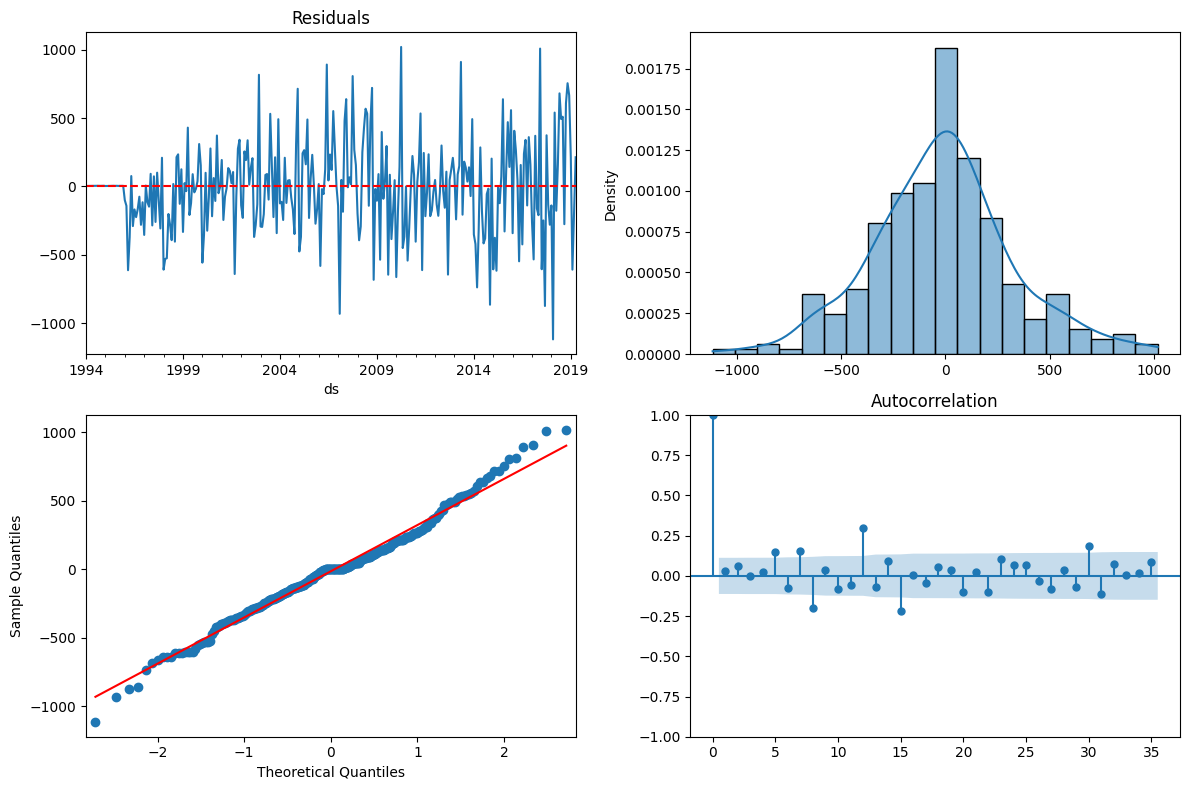

In [38]:
models = [AutoARIMA(seasonal=True, season_length=24, approximation=True)]
sf = StatsForecast(models=models, freq='M', n_jobs=-1)

train_with_reg = train.merge(regressors_train, how='left', on=['unique_id', 'ds'])
sf.fit(train_with_reg)

model_fitted = sf.fitted_[0][0]
residuals = model_fitted.model_['residuals']

residuals_series = pd.Series(residuals, index=train_with_reg['ds'])

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
residuals_series.plot(ax=axs[0, 0], title='Residuals')
axs[0, 0].axhline(0, color='r', linestyle='--')
sns.histplot(residuals_series, kde=True, ax=axs[0, 1], stat='density')
qqplot(residuals_series, line='s', ax=axs[1, 0])
plot_acf(residuals_series.dropna(), lags=35, ax=axs[1, 1])
plt.tight_layout()
plt.show()


In [ ]:
acorr_ljungbox(residuals_series.dropna(), return_df=True, lags=10)

,lb_stat,lb_pvalue
1,0.298625,0.584746
2,1.374840,0.502872
3,1.376604,0.711028
4,1.520025,0.823088
5,8.411719,0.134957
6,10.150555,0.118453
7,17.622003,0.013797
8,29.899408,0.000220
9,30.328624,0.000386
10,32.328584,0.000353


Остатки ведут себя не очень хорошо. На графике видно, что со временем они разлетаются всё сильнее (гетероскедастичность). Гистограмма похожа на нормальное распределение, но немного смещена влево от нуля. На Q–Q графике точки в середине лежат вдоль линии, а на краях уходят в стороны, что указывает на отклонение от нормальности в хвостах распределения. Тест Льюнга-Бокса показал, что остатки не автокоррелированы для большинства лагов до 6 (p-value > 0.05). Однако в ACF есть несколько выбросов за границы доверительного интервала на лагах 1, 7, 8, 15, 22 и 30. Это говорит о том, что остатки всё ещё связаны между собой на некоторых лагах, то есть модель не полностью уловила всю зависимость.
Модель работает не идеально: есть проблемы с дисперсией (гетероскедастичность), остаточной зависимостью на отдельных лагах и распределением остатков (отклонение от нормальности).

# Prophet модель

In [40]:
train_fp = train[['ds', 'y']]
test_fp = test[['ds', 'y']]

m = fp.Prophet()
m.fit(train_fp)
future = m.make_future_dataframe(periods=forecast_horizon, freq='M')
forecast_prophet = m.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [41]:
forecast_prophet.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1994-01-01,4053.906118,1492.201944,2773.192042,4053.906118,4053.906118,-1897.527191,-1897.527191,-1897.527191,-1897.527191,-1897.527191,-1897.527191,0.0,0.0,0.0,2156.378926
1,1994-02-01,4077.173581,2057.671521,3208.214020,4077.173581,4077.173581,-1416.662501,-1416.662501,-1416.662501,-1416.662501,-1416.662501,-1416.662501,0.0,0.0,0.0,2660.511081
2,1994-03-01,4098.189355,3263.109311,4447.059845,4098.189355,4098.189355,-211.828297,-211.828297,-211.828297,-211.828297,-211.828297,-211.828297,0.0,0.0,0.0,3886.361058
3,1994-04-01,4121.456819,3284.621056,4459.801685,4121.456819,4121.456819,-258.641522,-258.641522,-258.641522,-258.641522,-258.641522,-258.641522,0.0,0.0,0.0,3862.815297
4,1994-05-01,4143.973719,4048.144327,5217.373643,4143.973719,4143.973719,497.976635,497.976635,497.976635,497.976635,497.976635,497.976635,0.0,0.0,0.0,4641.950354


In [42]:
fig = px.line(title="Продажи алкоголя в США Prophet модель без настроек ")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='предсказание модель Prophet', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()


Так как фактический временной ряд имеет выраженную сезонность годовую, то изначальную обучающую выборку initial я взяла 2 года, далее так как ряд имеет различную сезонность, можно было взять 4 месяца, изначально я его рассмотрела, но на 6 месяцах MAPE получается лучше, и горизонт прогнозирования на год

In [43]:
df_cv = cross_validation(m, initial='730.5 days', period='180 days', horizon = '365 days')

INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-27 00:00:00 and 2018-04-01 00:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [44]:
res = performance_metrics(df_cv, rolling_window = 1)
res

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,365 days,293892.718652,542.118731,430.925055,0.051263,0.046691,0.051247,0.461957


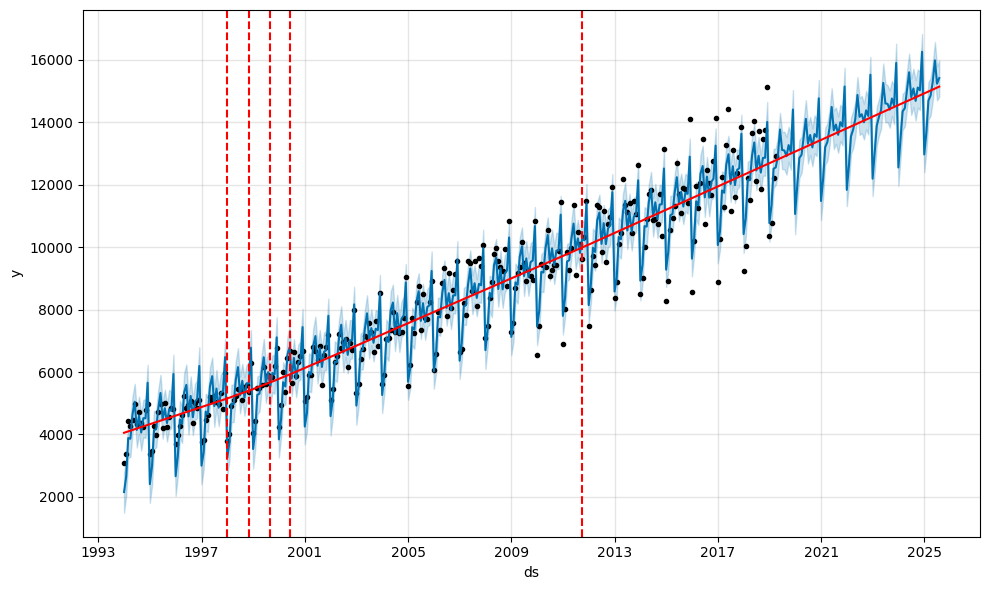

In [45]:
fig1 = m.plot(forecast_prophet)
a = add_changepoints_to_plot(fig1.gca(), m, forecast_prophet)

Как видим из графика временной ряд демонстрирует стабильный, выраженный линейный тренд. Отсутствие явных переломов или резких сдвигов в динамике ряда указывает на то, что модель тренда не требует высокой гибкости. Следовательно, влияние точек изменения тренда  на итоговый прогноз будет незначительным

In [46]:
holiday_months = [1, 7, 9, 11, 12]

holiday_list = []
for year in range(1994, 2026):
    for month in holiday_months:
        date = pd.Timestamp(year=year, month=month, day=15)
        holiday_list.append({
            'holiday': 'main_holiday',
            'ds': date
        })

holidays_prophet = pd.DataFrame(holiday_list)


In [47]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.5],
    'seasonality_prior_scale': [0.01, 0.1 , 5.0 , 10.0],
    'seasonality_mode':['multiplicative','additive'],
    'holidays_prior_scale':[3.0, 7.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

In [48]:
train_fp_with_reg = regressors.join(train_fp.set_index('ds'), how='inner')[['unemployment','y']].reset_index()
train_fp_with_reg

,ds,unemployment,y
0,1994-01-01,6.6,3075
1,1994-02-01,6.6,3377
2,1994-03-01,6.5,4443
3,1994-04-01,6.4,4261
4,1994-05-01,6.1,4460
...,...,...,...
299,2018-12-01,3.9,15135
300,2019-01-01,4.0,10353
301,2019-02-01,3.8,10764
302,2019-03-01,3.8,12228


In [49]:
mapes = []

for params in tqdm(all_params):
    m = fp.Prophet(**params, holidays=holidays_prophet)
    m.add_regressor('unemployment', mode=params['seasonality_mode'])
    m.fit(train_fp_with_reg)
    df_cv = cross_validation(m, initial='730.5 days', period='180 days', horizon = '365.25 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    mapes.append(df_p['mape'].values[0])

  0%|          | 0/48 [00:00<?, ?it/s]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
  2%|▏         | 1/48 [00:11<09:15, 11.82s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
  4%|▍         | 2/48 [00:23<09:02, 11.80s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


...

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
 96%|█████████▌| 46/48 [18:28<01:54, 57.45s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
 98%|█████████▊| 47/48 [19:13<00:53, 53.71s/it]INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
100%|██████████| 48/48 [20:12<00:00, 25.25s/it]


In [50]:
tuning_results = pd.DataFrame(all_params)
tuning_results['mape'] = mapes
tuning_results.sort_values(by='mape')

,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,holidays_prior_scale,mape
32,0.50,0.10,multiplicative,10.0,0.040583
30,0.50,0.10,multiplicative,3.0,0.040699
31,0.50,0.10,multiplicative,7.0,0.040728
7,0.01,0.10,multiplicative,7.0,0.040875
8,0.01,0.10,multiplicative,10.0,0.040917
6,0.01,0.10,multiplicative,3.0,0.040979
44,0.50,10.00,multiplicative,10.0,0.043912
36,0.50,5.00,multiplicative,3.0,0.044134
43,0.50,10.00,multiplicative,7.0,0.044218
20,0.01,10.00,multiplicative,10.0,0.044574


In [51]:
best_params = all_params[tuning_results.sort_values(by='mape').index[0]]
best_params

{'changepoint_prior_scale': 0.5,
 'seasonality_prior_scale': 0.1,
 'seasonality_mode': 'multiplicative',
 'holidays_prior_scale': 10.0}

In [52]:
m_tuned = fp.Prophet(holidays=holidays_prophet, **best_params)
m_tuned.add_regressor('unemployment')
m_tuned.fit(train_fp_with_reg)
future = m_tuned.make_future_dataframe(periods=forecast_horizon, freq='M')
future['unemployment'] = regressors['unemployment'].values[:len(future)]
forecast_tuned = m_tuned.predict(future)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [53]:
fig = px.line(title="Продажи алкоголя в США Prophet модель с подобранными параметрами")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='обучение', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='тест', line=dict(color='green'))
fig.add_scatter(x=forecast_prophet['ds'], y=forecast_prophet['yhat'], mode='lines', name='базовый прогноз', line=dict(color='red'))
fig.add_scatter(x=forecast_tuned['ds'], y=forecast_tuned['yhat'], mode='lines', name='предсказание с лучшими параметрами', line=dict(color='violet'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()

In [ ]:
df_cv_tuned = cross_validation(m_tuned, initial='730.5 days', period='180 days', horizon='365.25 days')
res_tuned= performance_metrics(df_cv_tuned, rolling_window = 1)
res_tuned

INFO:prophet:Making 46 forecasts with cutoffs between 1996-01-26 18:00:00 and 2018-03-31 18:00:00


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,365 days 06:00:00,177947.289801,421.83799,335.496847,0.040583,0.035116,0.0402,0.537071


Как видим из графика, модель Prophet с подобранными параметрами достаточно хорошо улавливает динамику поведения временного ряда продаж алкоголя, улавливает основной тренд и выраженные сезонные пики, включая праздничные периоды. Модель следует долгосрочному направлению роста и достаточно хорошо воспроизводит ежегодную сезонность, достигая небольшого MAPE = 4.06% по сравнению с другими моделями. Также если сравнивать с базовым прогнозом Prophet, вариант с подобранными параметрами лучше описывает дисперсию значений в начале временного ряда, однако в середине тестовой выборки модель уже не так точно улавливает разброс наблюдений.


# Статистические модели

# MSTL

In [55]:
models = [
    MSTL(
        season_length=[4, 6, 12],
        trend_forecaster=AutoARIMA()
        )
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_MSTL = sf.forecast(df=train, h=forecast_horizon)

fig = px.line(title="Продажи алкоголя в США  MSTL модель")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast_MSTL['ds'], y=forecast_MSTL['MSTL'], mode='lines', name='Предсказание MSTL модель', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Обьем продаж")
fig.show()

In [ ]:
def cv_mstl(train_data, n_splits=5):
    test_size = len(train_data) // (n_splits + 1)
    initial_size = len(train_data) - n_splits * test_size
    cv_rmse, cv_mape = [], []

    for i in range(n_splits):
        train_end = initial_size + i * test_size
        val_start, val_end = train_end, train_end + test_size
        if val_end > len(train_data):
            break

        train_cv = train_data.iloc[:train_end].copy()
        val_cv = train_data.iloc[val_start:val_end].copy()

        models_cv = [MSTL(season_length=[4, 6, 12], trend_forecaster=AutoARIMA())]
        sf_cv = StatsForecast(models=models_cv, freq='M', n_jobs=-1)
        sf_cv.fit(df=train_cv)
        forecast_cv = sf_cv.predict(h=len(val_cv))
        forecast_cv.columns = ['unique_id', 'ds', 'MSTL']

        rmse_val = np.sqrt(mean_squared_error(val_cv['y'].values, forecast_cv['MSTL'].values))
        mape_val = np.mean(np.abs((val_cv['y'].values - forecast_cv['MSTL'].values) / val_cv['y'].values)) * 100
        cv_rmse.append(rmse_val)
        cv_mape.append(mape_val)

    return {
        'rmse_mean': np.mean(cv_rmse),
        'mape_mean': np.mean(cv_mape)
    }

cv_results_mstl_manual = cv_mstl(train, n_splits=5)
print(f"MSTL: RMSE = {cv_results_mstl_manual['rmse_mean']:.2f} , MAPE = {cv_results_mstl_manual['mape_mean']:.2f}% ")



MSTL: RMSE = 559.82 , MAPE = 5.44% 


MSTL хорошо уловила сезонность и продолжила ее в тестовой выборке, что в целом похоже на динамику поведения ряда, но уловить возрастающую дисперсию не смогла, что видно на ухудшении метрик: MAPE 5.44% на 1,4 процентных пункта больше, чем у Prophet (4.06%).

# модель Theta

In [57]:
from statsforecast.theta import forecast_theta
models = [
    AutoTheta(season_length=4)
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_theta  = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Продажи алкоголя в США Theta модель")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast_theta['ds'], y=forecast_theta['AutoTheta'], mode='lines', name='Предсказание theta', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="обьем продаж")
fig.show()

In [58]:
def cv_theta(train_data, n_splits=5):
    test_size = len(train_data) // (n_splits + 1)
    initial_size = len(train_data) - n_splits * test_size
    cv_rmse, cv_mape = [], []

    for i in range(n_splits):
        train_end = initial_size + i * test_size
        val_start, val_end = train_end, train_end + test_size
        if val_end > len(train_data):
            break

        train_cv = train_data.iloc[:train_end].copy()
        val_cv = train_data.iloc[val_start:val_end].copy()

        models_cv = [AutoTheta(season_length=4)]
        sf_cv = StatsForecast(models=models_cv, freq='M', n_jobs=-1)
        sf_cv.fit(df=train_cv)
        forecast_cv = sf_cv.predict(h=len(val_cv))
        forecast_cv.columns = ['unique_id', 'ds', 'AutoTheta']

        rmse_val = np.sqrt(mean_squared_error(val_cv['y'].values, forecast_cv['AutoTheta'].values))
        mape_val = np.mean(np.abs((val_cv['y'].values - forecast_cv['AutoTheta'].values) / val_cv['y'].values)) * 100
        cv_rmse.append(rmse_val)
        cv_mape.append(mape_val)

    return {
        'rmse_mean': np.mean(cv_rmse),
        'mape_mean': np.mean(cv_mape)
    }

cv_results_theta_manual =cv_theta(train, n_splits=5)
print(f"Theta: RMSE = {cv_results_theta_manual['rmse_mean']:.2f}, MAPE = {cv_results_theta_manual['mape_mean']:.2f}%")


Theta: RMSE = 1029.44, MAPE = 10.09%


Theta модель смогла уловить общий возрастающий тренд продаж алкоголя, но плохо воспроизвела реальное поведение ряда, что заметно по более гладкой линии прогноза по сравнению с фактическими данными. Модель имеет худшую MAPE = 10.09% по сравнению с другими рассмотренными моделями

# Модель Holt-Winters

In [59]:
models = [
    HoltWinters(season_length=12)
]

sf = StatsForecast(models=models, freq='M', n_jobs=-1)

forecast_HW = sf.forecast(df=train, h=forecast_horizon)


fig = px.line(title="Продажи алкоголя в США HoltWinters модель")
fig.add_scatter(x=train['ds'], y=train['y'], mode='lines', name='Тренировочная выборка', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], mode='lines', name='Тестовая выборка', line=dict(color='green'))
fig.add_scatter(x=forecast_HW['ds'], y=forecast_HW['HoltWinters'], mode='lines', name='Предсказание Holt- Winters', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="обьем продаж")
fig.show()

In [ ]:
def cv_holtwinters(train_data, n_splits=5):
    test_size = len(train_data) // (n_splits + 1)
    initial_size = len(train_data) - n_splits * test_size
    cv_rmse, cv_mape = [], []

    for i in range(n_splits):
        train_end = initial_size + i * test_size
        val_start, val_end = train_end, train_end + test_size
        if val_end > len(train_data):
            break

        train_cv = train_data.iloc[:train_end].copy()
        val_cv = train_data.iloc[val_start:val_end].copy()

        models_cv = [HoltWinters(season_length=12)]
        sf_cv = StatsForecast(models=models_cv, freq='M', n_jobs=-1)
        sf_cv.fit(df=train_cv)
        forecast_cv = sf_cv.predict(h=len(val_cv))
        forecast_cv.columns = ['unique_id', 'ds', 'HoltWinters']

        rmse_val = np.sqrt(mean_squared_error(val_cv['y'].values, forecast_cv['HoltWinters'].values))
        mape_val = np.mean(np.abs((val_cv['y'].values - forecast_cv['HoltWinters'].values) / val_cv['y'].values)) * 100
        cv_rmse.append(rmse_val)
        cv_mape.append(mape_val)

    return {
        'rmse_mean': np.mean(cv_rmse),
        'mape_mean': np.mean(cv_mape)
    }

cv_results_hw_manual = cv_holtwinters(train, n_splits=5)
print(f"HoltWinters: RMSE = {cv_results_hw_manual['rmse_mean']:.2f}, MAPE = {cv_results_hw_manual['mape_mean']:.2f}%")

HoltWinters: RMSE = 668.67, MAPE = 6.19%


Модель Holt-Winters хорошо передает общий рост продаж алкоголя и сезонные колебания, а также визуально неплохо совпадает с тестовой выборкой. Прогноз не до конца отражает увеличивающуюся дисперсию в конце ряда. По метрикам она лучше базовых моделей SARIMA, SARIMAX, а также Theta, но все равно хуже, чем модель Prophet с подобранными параметрами.

In [ ]:
print(f"SARIMA: RMSE = {cv_results_sarima_manual['rmse_mean']:.2f}, MAPE = {cv_results_sarima_manual['mape_mean']:.2f}%")
print(f"SARIMAX: RMSE = {cv_results_sarimax_manual['rmse_mean']:.2f}, MAPE = {cv_results_sarimax_manual['mape_mean']:.2f}%")
print(f"Prophet_base: RMSE = {res['rmse'].values[0]:.2f}, MAPE = {res['mape'].values[0]*100:.2f}%")
print(f"Prophet_best: RMSE = {res_tuned['rmse'].values[0]:.2f}, MAPE = {res_tuned['mape'].values[0]*100:.2f}%")
print(f"MSTL модель: RMSE = {cv_results_mstl_manual['rmse_mean']:.2f}, MAPE = {cv_results_mstl_manual['mape_mean']:.2f}%")
print(f"Theta модель: RMSE = {cv_results_theta_manual['rmse_mean']:.2f}, MAPE = {cv_results_theta_manual['mape_mean']:.2f}%")
print(f"HoltWinters модель: RMSE = {cv_results_hw_manual['rmse_mean']:.2f}, MAPE = {cv_results_hw_manual['mape_mean']:.2f}%")

SARIMA: RMSE = 540.68, MAPE = 5.46%
SARIMAX: RMSE = 563.42, MAPE = 5.64%
Prophet_base: RMSE = 542.12, MAPE = 5.13%
Prophet_best: RMSE = 421.84, MAPE = 4.06%
MSTL модель: RMSE = 559.82, MAPE = 5.44%
Theta модель: RMSE = 1029.44, MAPE = 10.09%
HoltWinters модель: RMSE = 668.67, MAPE = 6.19%


Как видим из результатов сравнения метрик по кросс-валидации, лучшая модель для предсказания оказалась Prophet с подобранными параметрами (т.е. с использованием grid search). MAPE у Prophet (4.06%) на 1,4 процентных пункта ниже, чем у SARIMA (5.46%), на 1,6 процентных пункта ниже, чем у SARIMAX (5.64%), и на 6 процентных пунктов ниже, чем у модели Theta (10.09%). Prophet с подобранными параметрами показал лучшие результаты, так как учитывает мультипликативную сезонность, использует внешние регрессоры (уровень безработицы и праздничные дни), а также имеет оптимизированные гиперпараметры. Это позволяет модели достигать наименьшего MAPE (4.06%) и RMSE (421.84) и лучше воспроизводить сезонные пики и долгосрочный тренд продаж алкоголя.

# Финальная модель Prophet c подобранными параметрами(лучшая среди рассмотреных) с out of sample прогнозом на год вперед

In [63]:
all_data = pd.concat([train_fp, test_fp])
all_fp_with_reg = regressors.join( all_data.set_index('ds'), how='inner')[['unemployment', 'y']].reset_index().rename(columns={'index': 'ds'})

m_final = fp.Prophet(holidays=holidays_prophet, **best_params)
m_final.add_regressor('unemployment')
m_final.fit(all_fp_with_reg)

future = m_final.make_future_dataframe(periods=12, freq='M')

last_12_months = all_fp_with_reg['unemployment'].iloc[-12:].values
trend_slope = (last_12_months[-1] - last_12_months[0]) / 11

future_unemployment = []
for i in range(1, 13):
    predicted_value = last_12_months[-1] + trend_slope * i
    future_unemployment.append(max(0, predicted_value))

future['unemployment'] = list(all_fp_with_reg['unemployment'].values) + future_unemployment

forecast_final = m_final.predict(future)

last_date = all_fp_with_reg['ds'].max()
future_forecast = forecast_final[forecast_final['ds'] > last_date]

fig = px.line(title="Продажи алкоголя в США Prophet (финальная модель)")
fig.add_scatter(x=train_fp['ds'], y=train_fp['y'], mode='lines', name='Тренировочная выборка',line=dict(color='blue'))
fig.add_scatter(x=test_fp['ds'], y=test_fp['y'], mode='lines', name='Тестовая выборка',line=dict(color='green'))
fig.add_scatter(x=forecast_final['ds'], y=forecast_final['yhat'], mode='lines', name='Прогноз Prophet', line=dict(color='red'))
fig.add_vline( x=last_date,line_width=2, line_dash="dash", line_color="black")
fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Объем продаж")

fig.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Финальная Prophet модель out-of-sample  с прогнозом на год хорошо сохраняет восходящий тренд и отражает тенденцию к росту дисперсии значений во времени. Сезонные колебания также воспроизводятся достаточно точно, что визуально делает прогноз близким к наблюдаемой динамике ряда.